In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import time
import os
import re
import warnings
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
import nltk
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import tempfile
import torchmetrics

In [2]:
warnings.filterwarnings('ignore')

In [3]:
device = torch.device("cuda")

## Loading data

In [ ]:
from preprocess import load_data, prepare_data

In [ ]:
df = load_data('../data/enps_full_2025.xlsx')
df = prepare_data(df, split=False)

train_indices = np.load('../data/train_indices.npy')
test_indices = np.load('../data/test_indices.npy')

df['Y_cat'] = df['Y'] - 2

df_train, df_test = df.iloc[train_indices], df.iloc[test_indices]

df_test = df_test[df_test.Y>1]
df_train = df_train[df_train.Y>1]

## Tokenization

In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased', do_lower_case=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [7]:
def preprocessing_for_bert(data, max_len=64):
    
    input_ids = []
    attention_masks = []

    for text in tqdm(data):

        encoded_sent = tokenizer.encode_plus(
            text=text,  
            add_special_tokens=True,       
            max_length=max_len,                  
            pad_to_max_length=True,       
            truncation=True,         
            return_attention_mask=True 
            )
        
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    input_ids = torch.tensor(input_ids)
    attention_masks = torch.tensor(attention_masks)

    return input_ids, attention_masks

In [8]:
train_inputs, train_masks = preprocessing_for_bert(np.array(df_train['A']))
val_inputs, val_masks = preprocessing_for_bert(np.array(df_test['A']))

100%|██████████| 3271/3271 [00:02<00:00, 1520.54it/s]


In [9]:
train_labels = torch.tensor(np.array(df_train['Y_cat']))
val_labels = torch.tensor(np.array(df_test['Y_cat']))

# train_labels = nn.functional.one_hot(train_labels)
# val_labels = nn.functional.one_hot(val_labels)

train_scores = torch.tensor(np.array(df_train['S']), dtype=torch.float32)
val_scores = torch.tensor(np.array(df_test['S']), dtype=torch.float32)

batch_size = 64

train_data = TensorDataset(train_inputs, train_masks, train_scores, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_scores, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

## Model

In [ ]:
# class BERTClassifier(nn.Module):
    
#     def __init__(self, bert, task='binary', n_classes=None, device='cuda'):

#         super(BERTClassifier, self).__init__()
        
#         self.bert = bert
#         self.task = task
#         self.n_classes = n_classes
#         self.dropout = nn.Dropout(0.1)
#         self.silu =  nn.SiLU()
#         self.fc1 = nn.Linear(768, 128)
#         self.fcs1 = nn.Linear(1, 32)
#         self.fcs2 = nn.Linear(32, 64)
#         self.fc2 = nn.Linear(192, 1) if self.task=='binary' else nn.Linear(192, n_classes)
#         self.output = nn.Sigmoid() if self.task=='binary' else nn.Softmax()
#         self.best_metric = 0
#         self.epoch = 0
#         self.history = {'loss' : {'train_loss' : [], 'val_loss' : []}, 
#                         'metrics' : {'precision': [], 'recall': [], 'specificity' : [], 'f1' : []}}
#         self.device = device
#         self.to(device)

#     def forward(self, x, s, mask):
  
#         _, x = self.bert(x, attention_mask=mask).values()
#         x = self.fc1(x)
#         x = self.silu(x)
#         s = self.fcs1(s.unsqueeze(1))
#         s = self.silu(s)
#         s = self.fcs2(s)
#         s = self.silu(s)
#         x = torch.concat((x,s), axis=1)
#         x = self.dropout(x)
#         x = self.fc2(x)
#         x = self.output(x)
        
#         return x

#     def predict(self, data, thresh=0.5):
        
#         model.eval()
#         predictions = []
        
#         with tqdm(total = len(data)) as tq:
#             for batch in data:
#                 b_data = tuple(t.to(self.device) for t in batch)
#                 if len(b_data) == 4:
#                     b_input_ids, b_attn_mask, b_scores, b_labels = b_data
#                 else:
#                     b_input_ids, b_attn_mask, b_scores = b_data
#                 with torch.no_grad():
#                     preds = self.forward(b_input_ids, b_scores, b_attn_mask).cpu()
#                 predictions.extend(preds)
#                 tq.update(1)
                
#         predictions = np.array(predictions)

#         if self.task == 'binary':
#             return (predictions.reshape(-1) > thresh).astype(int)
            
#         return predictions.argmax(axis=1).astype(int)

#     def fit(self, train_dataloader, val_dataloader=None, val_metric = 'f1', epochs=5, early_stopping = None, evaluation=True, save_best=True):

#         epochs_without_improvements = 0
        
#         for epoch in range(self.epoch, self.epoch + epochs):
    
#             t_start = time.time()
    
#             total_loss = 0.
    
#             self.train()
    
#             with tqdm(total = len(train_dataloader)) as tq:
                
#                 for step, batch in enumerate(train_dataloader):
                    
#                     self.optimizer.zero_grad()
#                     b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
#                     b_labels = b_labels.reshape(-1,1)
#                     pred = self.forward(b_input_ids, b_scores, b_attn_mask)
#                     loss = self.loss_fn(pred, b_labels)
#                     loss_value = loss.item()
#                     total_loss += loss_value
        
#                     loss.backward()
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#                     self.optimizer.step()
#                     self.scheduler.step()
#                     tq.update(1)
#                     tq.set_description("Loss %s" % loss_value)
            
    
#             avg_train_loss = total_loss / len(train_dataloader)
            
#             self.history['loss']['train_loss'].append(avg_train_loss)

#             self.epoch += 1

#             epochs_without_improvements += 1
    
#             if evaluation == True:
    
#                 val_loss, val_results = self.evaluate(val_dataloader)

#                 self.history['loss']['val_loss'].append(val_loss)
#                 for metric in val_results:
#                     self.history['metrics'][metric].append(val_results[metric].cpu())
    
#                 time_elapsed = time.time() - t_start
    
                
#                 if val_results[val_metric] > self.best_metric:
#                     self.best_metric = val_results[val_metric]
#                     epochs_without_improvements = 0
                    
#                     if save_best:
#                         self.save_checkpoint('best_ckpt.pt', self.epoch)
                        
#                 self.best_metric = max(self.best_metric, val_results[val_metric])
                
#                 print(f"{epoch + 1:^7} | {'-':^7} | train_loss {avg_train_loss:^12.6f} | val_loss {val_loss:^10.6f} | precision {val_results['precision']:^9.4f} | recall {val_results['recall']:^9.4f} | specificity {val_results['specificity']:^9.4f} | f1 {val_results['f1']:^9.4f} | {time_elapsed:^9.2f}")
    
#                 if early_stopping:
#                     if epochs_without_improvements == early_stopping:
#                         break
                    
#         self.save_checkpoint('last_ckpt.pt', self.epoch)


#     def evaluate(self, val_dataloader):
    
#         val_loss = []
        
#         if self.task == 'binary':
#             metrics = {
#                 'precision': torchmetrics.Precision(task='binary', threshold=0.5),
#                 'recall': torchmetrics.Recall(task='binary', threshold=0.5),
#                 'specificity': torchmetrics.Specificity(task='binary', threshold=0.5),
#                 'f1': torchmetrics.F1Score(task='binary', threshold=0.5)
#             }
#         else: 
#             metrics = {
#                 'precision': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
#                 'recall': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
#                 'specificity': torchmetrics.Specificity(task='multiclass', num_classes=num_classes, average='macro'),
#                 'f1': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro')
#             }
        
#         for metric in metrics.values():
#             metric.to(self.device)
        
#         model.eval()
#         with torch.no_grad():
#             with tqdm(total = len(val_dataloader)) as tq:
#                 for batch in val_dataloader:
                    
#                     b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
#                     b_labels = b_labels.reshape(-1, 1)
                    
#                     pred = self.forward(b_input_ids, b_scores, b_attn_mask)
            
#                     loss = self.loss_fn(pred, b_labels)
#                     val_loss.append(loss.item())
            
#                     for metric in metrics.values():
#                         metric.update(pred, b_labels)
                    
#                     tq.update(1)
        
#         results = {name: metric.compute() for name, metric in metrics.items()}
        
#         for metric in metrics.values():
#             metric.reset()
            
#         return np.mean(val_loss), results
    
#     def save_checkpoint(self, filename, epoch):
#         state = {
#             'epoch': epoch,
#             'model': self,
#             }
#         torch.save(state, filename)

#     def set_loss_fn(self, loss_fn):
#         self.loss_fn = loss_fn

#     def set_optimizer(self, optimizer):
#         self.optimizer = optimizer

#     def set_scheduler(self, scheduler):
#         self.scheduler = scheduler

    
#     def load_best_model(self, path='bert_multiclass/best_ckpt.pt'):
#         ckpt = torch.load(path)
#         print(f'Model loaded from epoch {ckpt["epoch"]}')
#         return ckpt['model']

#     def load_last_model(self, path='bert_multiclass/last_ckpt.pt'):
#         ckpt = torch.load(path)
#         print(f'Model loaded from epoch {ckpt["epoch"]}')
#         return ckpt['model']

#     def plot_history(self):
#         fig, ax = plt.subplots(figsize=(12,4))
#         ax.plot(self.history['loss']['train_loss'],label='train_loss')
#         ax.plot(self.history['loss']['val_loss'],label='val_loss')
#         ax.set_xlabel('epoch')
#         ax.set_ylabel('loss')
#         ax.legend()
#         plt.show()

#         metric_keys = list(self.history['metrics'].keys())
#         num_metrics = len(metric_keys)
        
#         fig, axs = plt.subplots(len(metric_keys), 1, figsize=(12,4*num_metrics))
#         axs = axs.ravel()
#         for ax, metric_name in zip(axs, metric_keys):
#             ax.plot(self.history['metrics'][metric_name])
#             ax.set_xlabel('epoch')
#             ax.set_ylabel(metric_name)
            
#         plt.show()

In [ ]:
# ckpt = torch.load('bert_binary/best_ckpt.pt')
# print(f'Model loaded from epoch {ckpt["epoch"]}')
# bert = ckpt['model'].bert

In [ ]:
class BERTMultiClassifier(nn.Module):
    
    def __init__(self, bert, task='binary', n_classes=None, device='cuda'):

        super(BERTMultiClassifier, self).__init__()
        
        self.bert = bert
        self.task = task
        self.n_classes = n_classes

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.SiLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Dropout(0.1),
            

            nn.Linear(256, 512),
            nn.SiLU(),
            nn.Dropout(0.05),

            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Dropout(0.05),
            
            nn.Linear(512, n_classes)
        )
        
        self.best_metric = 0
        self.epoch = 0
        self.history = {'loss' : {'train_loss' : [], 'val_loss' : []}, 
                        'metrics' : {'precision': [], 'recall': [], 'specificity' : [], 'f1' : []}}
        self.device = device
        self.to(device)

    def forward(self, x, s, mask):
  
        _, x = self.bert(x, attention_mask=mask).values()
        x = self.classifier(x)

        return x

    def predict(self, data, thresh=0.5):
        
        self.eval()
        predictions = []
        
        with tqdm(total = len(data)) as tq:
            for batch in data:
                b_data = tuple(t.to(self.device) for t in batch)
                if len(b_data) == 4:
                    b_input_ids, b_attn_mask, b_scores, b_labels = b_data
                else:
                    b_input_ids, b_attn_mask, b_scores = b_data
                with torch.no_grad():
                    preds = self.forward(b_input_ids, b_scores, b_attn_mask).cpu()
                predictions.extend(preds)
                tq.update(1)
                
        predictions = np.array(predictions)

        if self.task == 'binary':
            return (predictions.reshape(-1) > thresh).astype(int)
            
        return predictions.argmax(axis=1).astype(int)

    def fit(self, train_dataloader, val_dataloader=None, val_metric = 'f1', epochs=5, early_stopping = None, evaluation=True, save_best=True):

        epochs_without_improvements = 0
        
        for epoch in range(self.epoch, self.epoch + epochs):
    
            t_start = time.time()
    
            total_loss = 0.
    
            self.train()
    
            with tqdm(total = len(train_dataloader)) as tq:
                
                for step, batch in enumerate(train_dataloader):
                    
                    self.optimizer.zero_grad()
                    b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
                    # b_labels = b_labels.reshape(-1,1)
                    pred = self.forward(b_input_ids, b_scores, b_attn_mask)
                    loss = self.loss_fn(pred, b_labels)
                    loss_value = loss.item()
                    total_loss += loss_value
        
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    self.optimizer.step()
                    self.scheduler.step()
                    tq.update(1)
                    tq.set_description("Loss %s" % loss_value)
            
    
            avg_train_loss = total_loss / len(train_dataloader)
            
            self.history['loss']['train_loss'].append(avg_train_loss)

            self.epoch += 1

            epochs_without_improvements += 1
    
            if evaluation == True:
    
                val_loss, val_results = self.evaluate(val_dataloader)

                self.history['loss']['val_loss'].append(val_loss)
                for metric in val_results:
                    self.history['metrics'][metric].append(val_results[metric].cpu())
    
                time_elapsed = time.time() - t_start
    
                
                if val_results[val_metric] > self.best_metric:
                    self.best_metric = val_results[val_metric]
                    epochs_without_improvements = 0
                    
                    if save_best:
                        self.save_checkpoint('best_ckpt.pt', self.epoch)
                        
                self.best_metric = max(self.best_metric, val_results[val_metric])
                
                print(f"{epoch + 1:^7} | {'-':^7} | train_loss {avg_train_loss:^12.6f} | val_loss {val_loss:^10.6f} | precision {val_results['precision']:^9.4f} | recall {val_results['recall']:^9.4f} | specificity {val_results['specificity']:^9.4f} | f1 {val_results['f1']:^9.4f} | {time_elapsed:^9.2f}")
    
                if early_stopping:
                    if epochs_without_improvements == early_stopping:
                        break
                    
        self.save_checkpoint('last_ckpt.pt', self.epoch)


    def evaluate(self, val_dataloader):
    
        val_loss = []
        
        if self.task == 'binary':
            metrics = {
                'precision': torchmetrics.Precision(task='binary', threshold=0.5),
                'recall': torchmetrics.Recall(task='binary', threshold=0.5),
                'specificity': torchmetrics.Specificity(task='binary', threshold=0.5),
                'f1': torchmetrics.F1Score(task='binary', threshold=0.5)
            }
        else: 
            metrics = {
                'precision': torchmetrics.Precision(task='multiclass', num_classes=self.n_classes, average='macro'),
                'recall': torchmetrics.Recall(task='multiclass', num_classes=self.n_classes, average='macro'),
                'specificity': torchmetrics.Specificity(task='multiclass', num_classes=self.n_classes, average='macro'),
                'f1': torchmetrics.F1Score(task='multiclass', num_classes=self.n_classes, average='macro')
            }
        
        for metric in metrics.values():
            metric.to(self.device)
        
        self.eval()
        with torch.no_grad():
            with tqdm(total = len(val_dataloader)) as tq:
                for batch in val_dataloader:
                    
                    b_input_ids, b_attn_mask, b_scores, b_labels = tuple(t.to(self.device) for t in batch)
                    # b_labels = b_labels.reshape(-1, 1)
                    
                    pred = self.forward(b_input_ids, b_scores, b_attn_mask)
            
                    loss = self.loss_fn(pred, b_labels)
                    val_loss.append(loss.item())
            
                    for metric in metrics.values():
                        metric.update(pred, b_labels)
                    
                    tq.update(1)
        
        results = {name: metric.compute() for name, metric in metrics.items()}
        
        for metric in metrics.values():
            metric.reset()
            
        return np.mean(val_loss), results
    
    def save_checkpoint(self, filename, epoch):
        state = {
            'epoch': epoch,
            'model': self,
            }
        torch.save(state, filename)

    def set_loss_fn(self, loss_fn):
        self.loss_fn = loss_fn

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_scheduler(self, scheduler):
        self.scheduler = scheduler

    
    def load_best_model(self, path='bert_multiclass/best_ckpt.pt'):
        ckpt = torch.load(path)
        print(f'Model loaded from epoch {ckpt["epoch"]}')
        return ckpt['model']

    def load_last_model(self, path='bert_multiclass/last_ckpt.pt'):
        ckpt = torch.load(path)
        print(f'Model loaded from epoch {ckpt["epoch"]}')
        return ckpt['model']

    def plot_history(self):
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(self.history['loss']['train_loss'],label='train_loss')
        ax.plot(self.history['loss']['val_loss'],label='val_loss')
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
        plt.show()

        metric_keys = list(self.history['metrics'].keys())
        num_metrics = len(metric_keys)
        
        fig, axs = plt.subplots(len(metric_keys), 1, figsize=(12,4*num_metrics))
        axs = axs.ravel()
        for ax, metric_name in zip(axs, metric_keys):
            ax.plot(self.history['metrics'][metric_name])
            ax.set_xlabel('epoch')
            ax.set_ylabel(metric_name)
            
        plt.show()
        
        

In [ ]:
model = BERTMultiClassifier(None, task='multiclass', n_classes=28)

model = model.load_best_model('bert_multiclass/best_ckpt.pt')

Model loaded from epoch 221


## Training

In [14]:
# for param in model.bert.parameters():
#     param.requires_grad = False
    
# epochs = 100
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 1e-4, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.03 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, val_metric = 'f1', early_stopping=early_stopping)

# model.plot_history()

In [15]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# epochs = 100
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.03 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, val_metric = 'f1', early_stopping=early_stopping)

# model.plot_history()

In [16]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[11].parameters():
#     param.requires_grad = True


# epochs = 50
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.06 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

# model.plot_history()

In [17]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[11].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[10].parameters():
#     param.requires_grad = True


# epochs = 50
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.06 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

# model.plot_history()

In [18]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[11].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[10].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[9].parameters():
#     param.requires_grad = True


# epochs = 50
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.06 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

# model.plot_history()

In [19]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[11].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[10].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[9].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[8].parameters():
#     param.requires_grad = True


# epochs = 50
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.06 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

# model.plot_history()

In [20]:
# model = model.load_best_model()

# for param in model.bert.parameters():
#     param.requires_grad = False

# for param in model.bert.pooler.parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[11].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[10].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[9].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[8].parameters():
#     param.requires_grad = True

# for param in model.bert.encoder.layer[7].parameters():
#     param.requires_grad = True


# epochs = 50
# early_stopping = 10

# model.set_loss_fn(nn.CrossEntropyLoss())
# model.set_optimizer(AdamW(model.parameters(), lr = 5e-5, eps=1e-8))
# total_steps = len(train_dataloader) * epochs
# model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
#                                             num_warmup_steps = 0.06 * total_steps,
#                                             num_training_steps = total_steps))

# model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

# model.plot_history()

100%|██████████| 52/52 [00:05<00:00,  9.51it/s]


  222   |    -    | train_loss   0.044570   | val_loss  2.214584  | precision  0.6091   | recall  0.5793   | specificity  0.9897   | f1  0.5874   |   45.57  


100%|██████████| 52/52 [00:05<00:00,  9.64it/s]


  223   |    -    | train_loss   0.037919   | val_loss  2.441503  | precision  0.6062   | recall  0.5943   | specificity  0.9896   | f1  0.5952   |   44.90  


100%|██████████| 52/52 [00:05<00:00,  9.62it/s]


...

  244   |    -    | train_loss   0.028891   | val_loss  2.980316  | precision  0.6271   | recall  0.6097   | specificity  0.9902   | f1  0.6124   |   44.98  


100%|██████████| 52/52 [00:05<00:00,  9.69it/s]


  245   |    -    | train_loss   0.019373   | val_loss  3.087901  | precision  0.6172   | recall  0.5990   | specificity  0.9900   | f1  0.6049   |   44.94  


100%|██████████| 52/52 [00:05<00:00,  9.64it/s]


  246   |    -    | train_loss   0.018568   | val_loss  3.328622  | precision  0.6329   | recall  0.6079   | specificity  0.9900   | f1  0.6152   |   44.98  


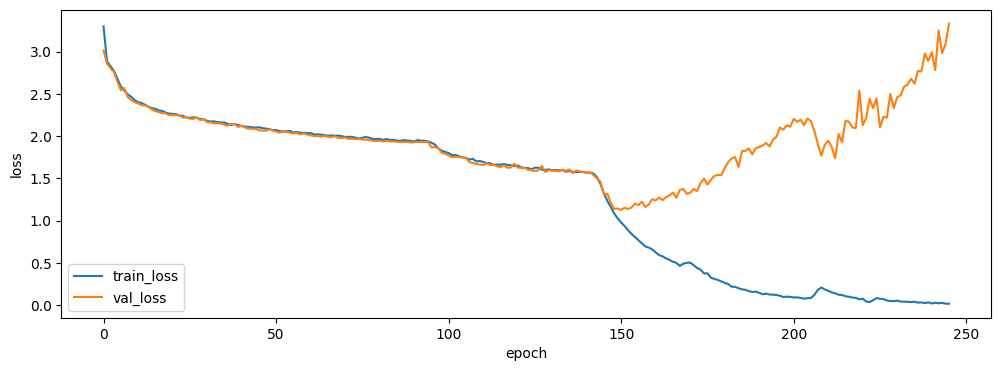

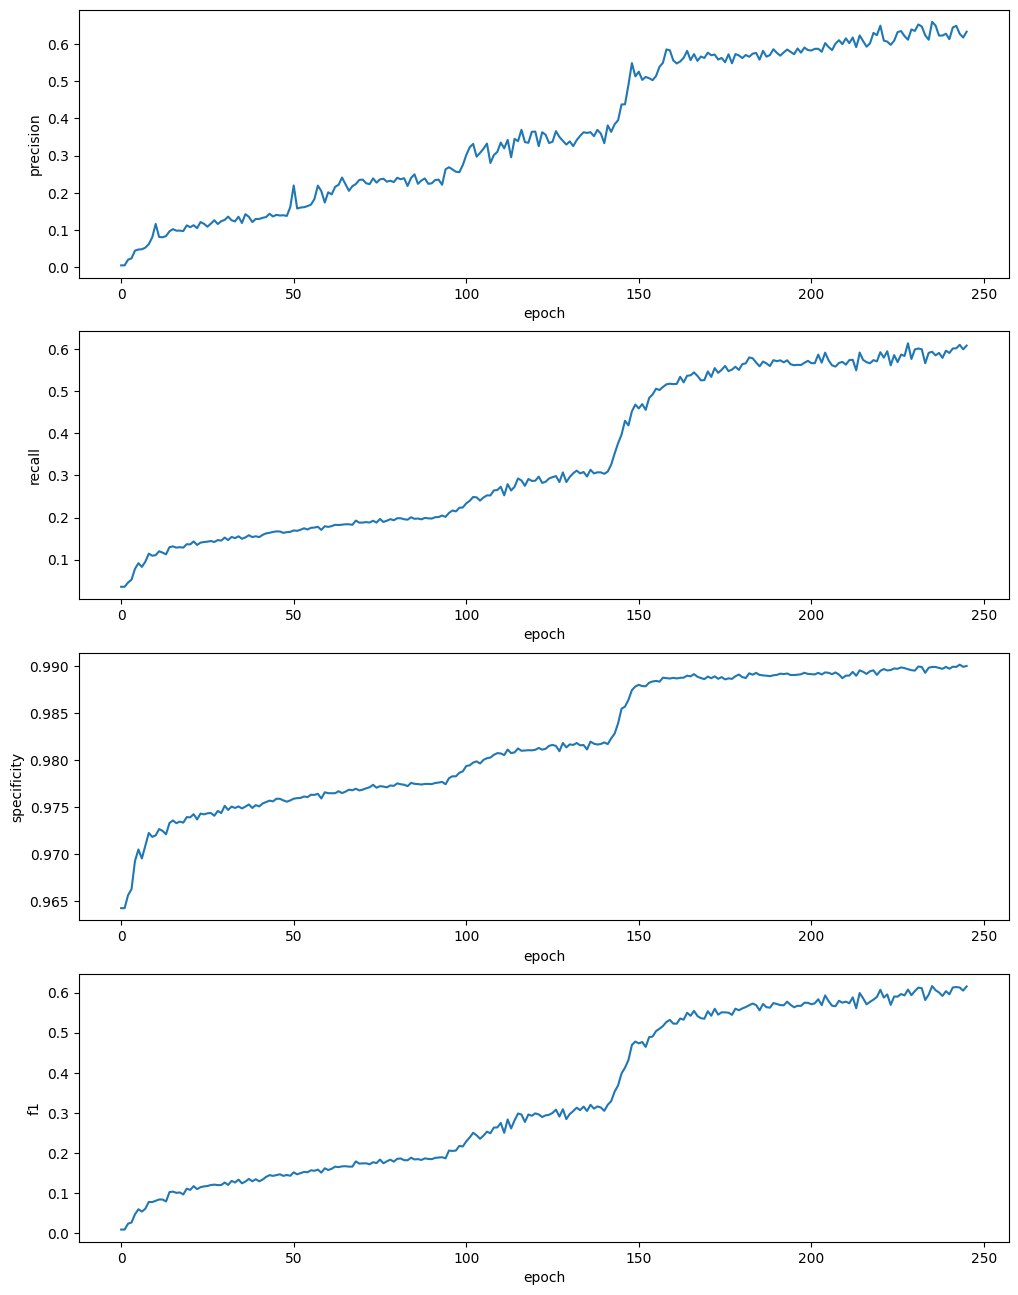

tensor(0.6161, device='cuda:0')


In [21]:
# model = model.load_best_model()

for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.pooler.parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[11].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[10].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[9].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[8].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[7].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[6].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[5].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[4].parameters():
    param.requires_grad = True


epochs = 50
early_stopping = 10

model.set_loss_fn(nn.CrossEntropyLoss())
model.set_optimizer(AdamW(model.parameters(), lr = 3e-5, eps=1e-8))
total_steps = len(train_dataloader) * epochs
model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
                                            num_warmup_steps = 0.06 * total_steps,
                                            num_training_steps = total_steps))

model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

model.plot_history()

print(model.best_metric)

Model loaded from epoch 236


100%|██████████| 52/52 [00:05<00:00,  9.69it/s]


  237   |    -    | train_loss   0.023779   | val_loss  2.695125  | precision  0.6637   | recall  0.5970   | specificity  0.9902   | f1  0.6206   |   53.88  


100%|██████████| 52/52 [00:05<00:00,  9.65it/s]


  238   |    -    | train_loss   0.016936   | val_loss  2.868425  | precision  0.6757   | recall  0.6049   | specificity  0.9902   | f1  0.6273   |   53.92  


...

  246   |    -    | train_loss   0.015540   | val_loss  3.023565  | precision  0.6426   | recall  0.6015   | specificity  0.9902   | f1  0.6143   |   53.88  


100%|██████████| 52/52 [00:05<00:00,  9.69it/s]


  247   |    -    | train_loss   0.009384   | val_loss  3.167615  | precision  0.6470   | recall  0.5953   | specificity  0.9900   | f1  0.6097   |   53.89  


100%|██████████| 52/52 [00:05<00:00,  9.66it/s]


  248   |    -    | train_loss   0.012773   | val_loss  3.163734  | precision  0.6575   | recall  0.5912   | specificity  0.9900   | f1  0.6100   |   53.90  


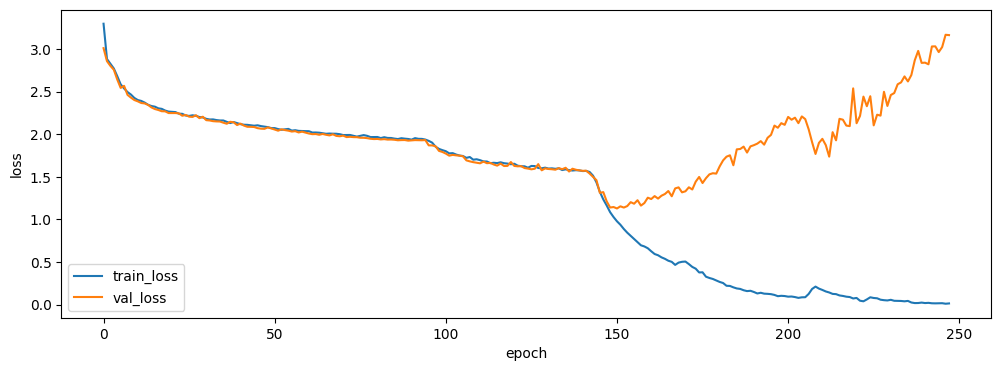

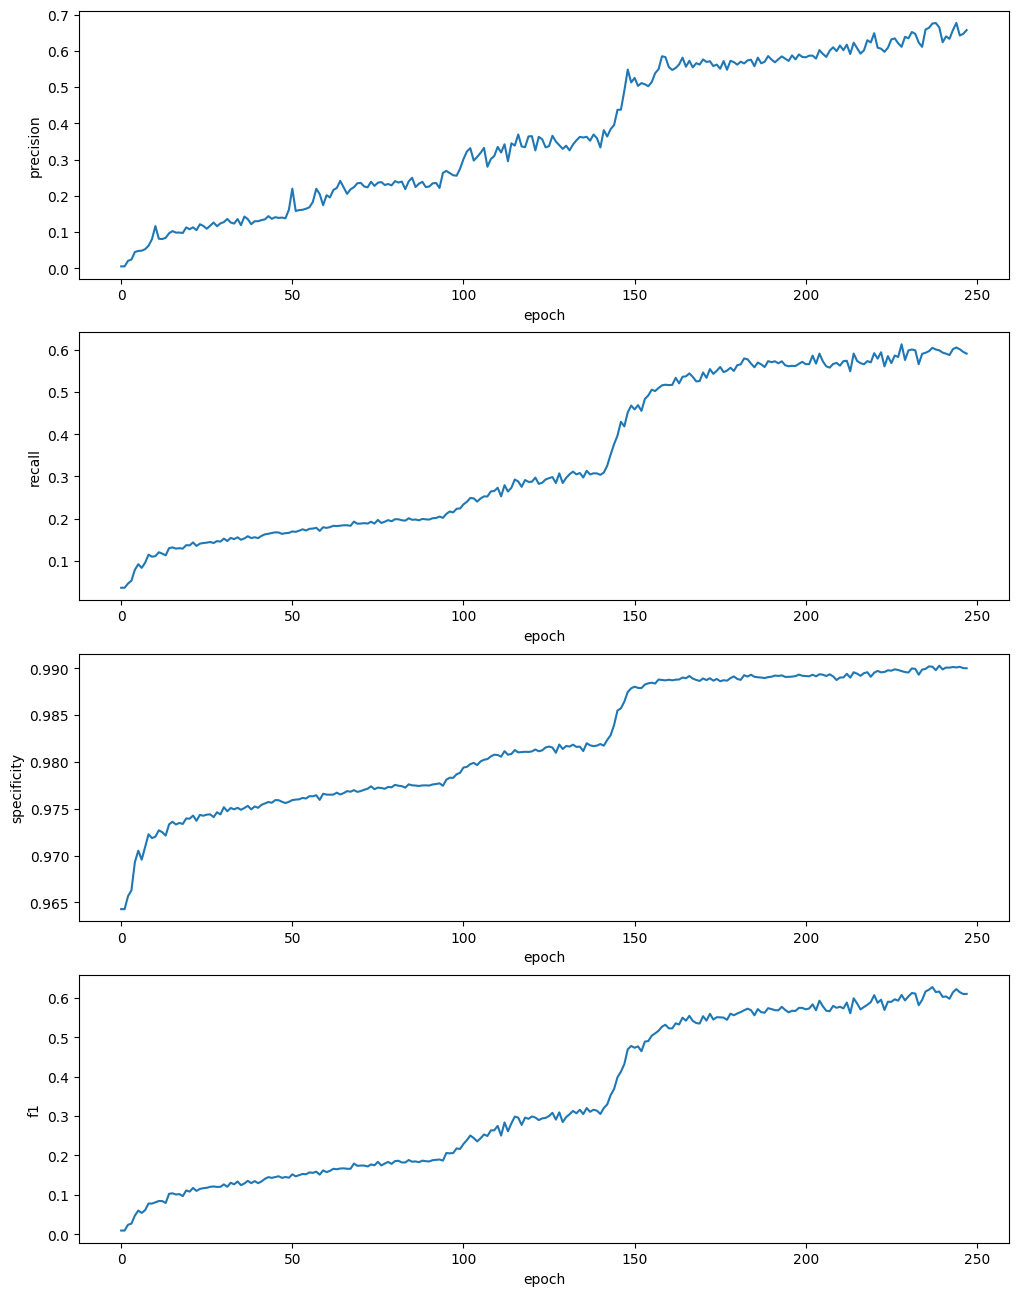

tensor(0.6273, device='cuda:0')


In [22]:
model = model.load_best_model()

for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.pooler.parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[11].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[10].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[9].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[8].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[7].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[6].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[5].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[4].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[3].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[2].parameters():
    param.requires_grad = True

for param in model.bert.encoder.layer[1].parameters():
    param.requires_grad = True

epochs = 50
early_stopping = 10

model.set_loss_fn(nn.CrossEntropyLoss())
model.set_optimizer(AdamW(model.parameters(), lr = 1e-5, eps=1e-8))
total_steps = len(train_dataloader) * epochs
model.set_scheduler(get_linear_schedule_with_warmup(model.optimizer,
                                            num_warmup_steps = 0.06 * total_steps,
                                            num_training_steps = total_steps))

model.fit(train_dataloader, val_dataloader, epochs=epochs, evaluation=True, early_stopping=early_stopping)

model.plot_history()

print(model.best_metric)

## Evaluation

In [23]:
model = model.load_best_model()

Model loaded from epoch 238


In [24]:
model.best_metric

tensor(0.6273, device='cuda:0')

In [25]:
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=1)

In [26]:
pred = model.predict(val_dataloader)
y_true = np.array(df_test['Y_cat'])

100%|██████████| 3271/3271 [00:24<00:00, 131.71it/s]


In [27]:
import seaborn as sns

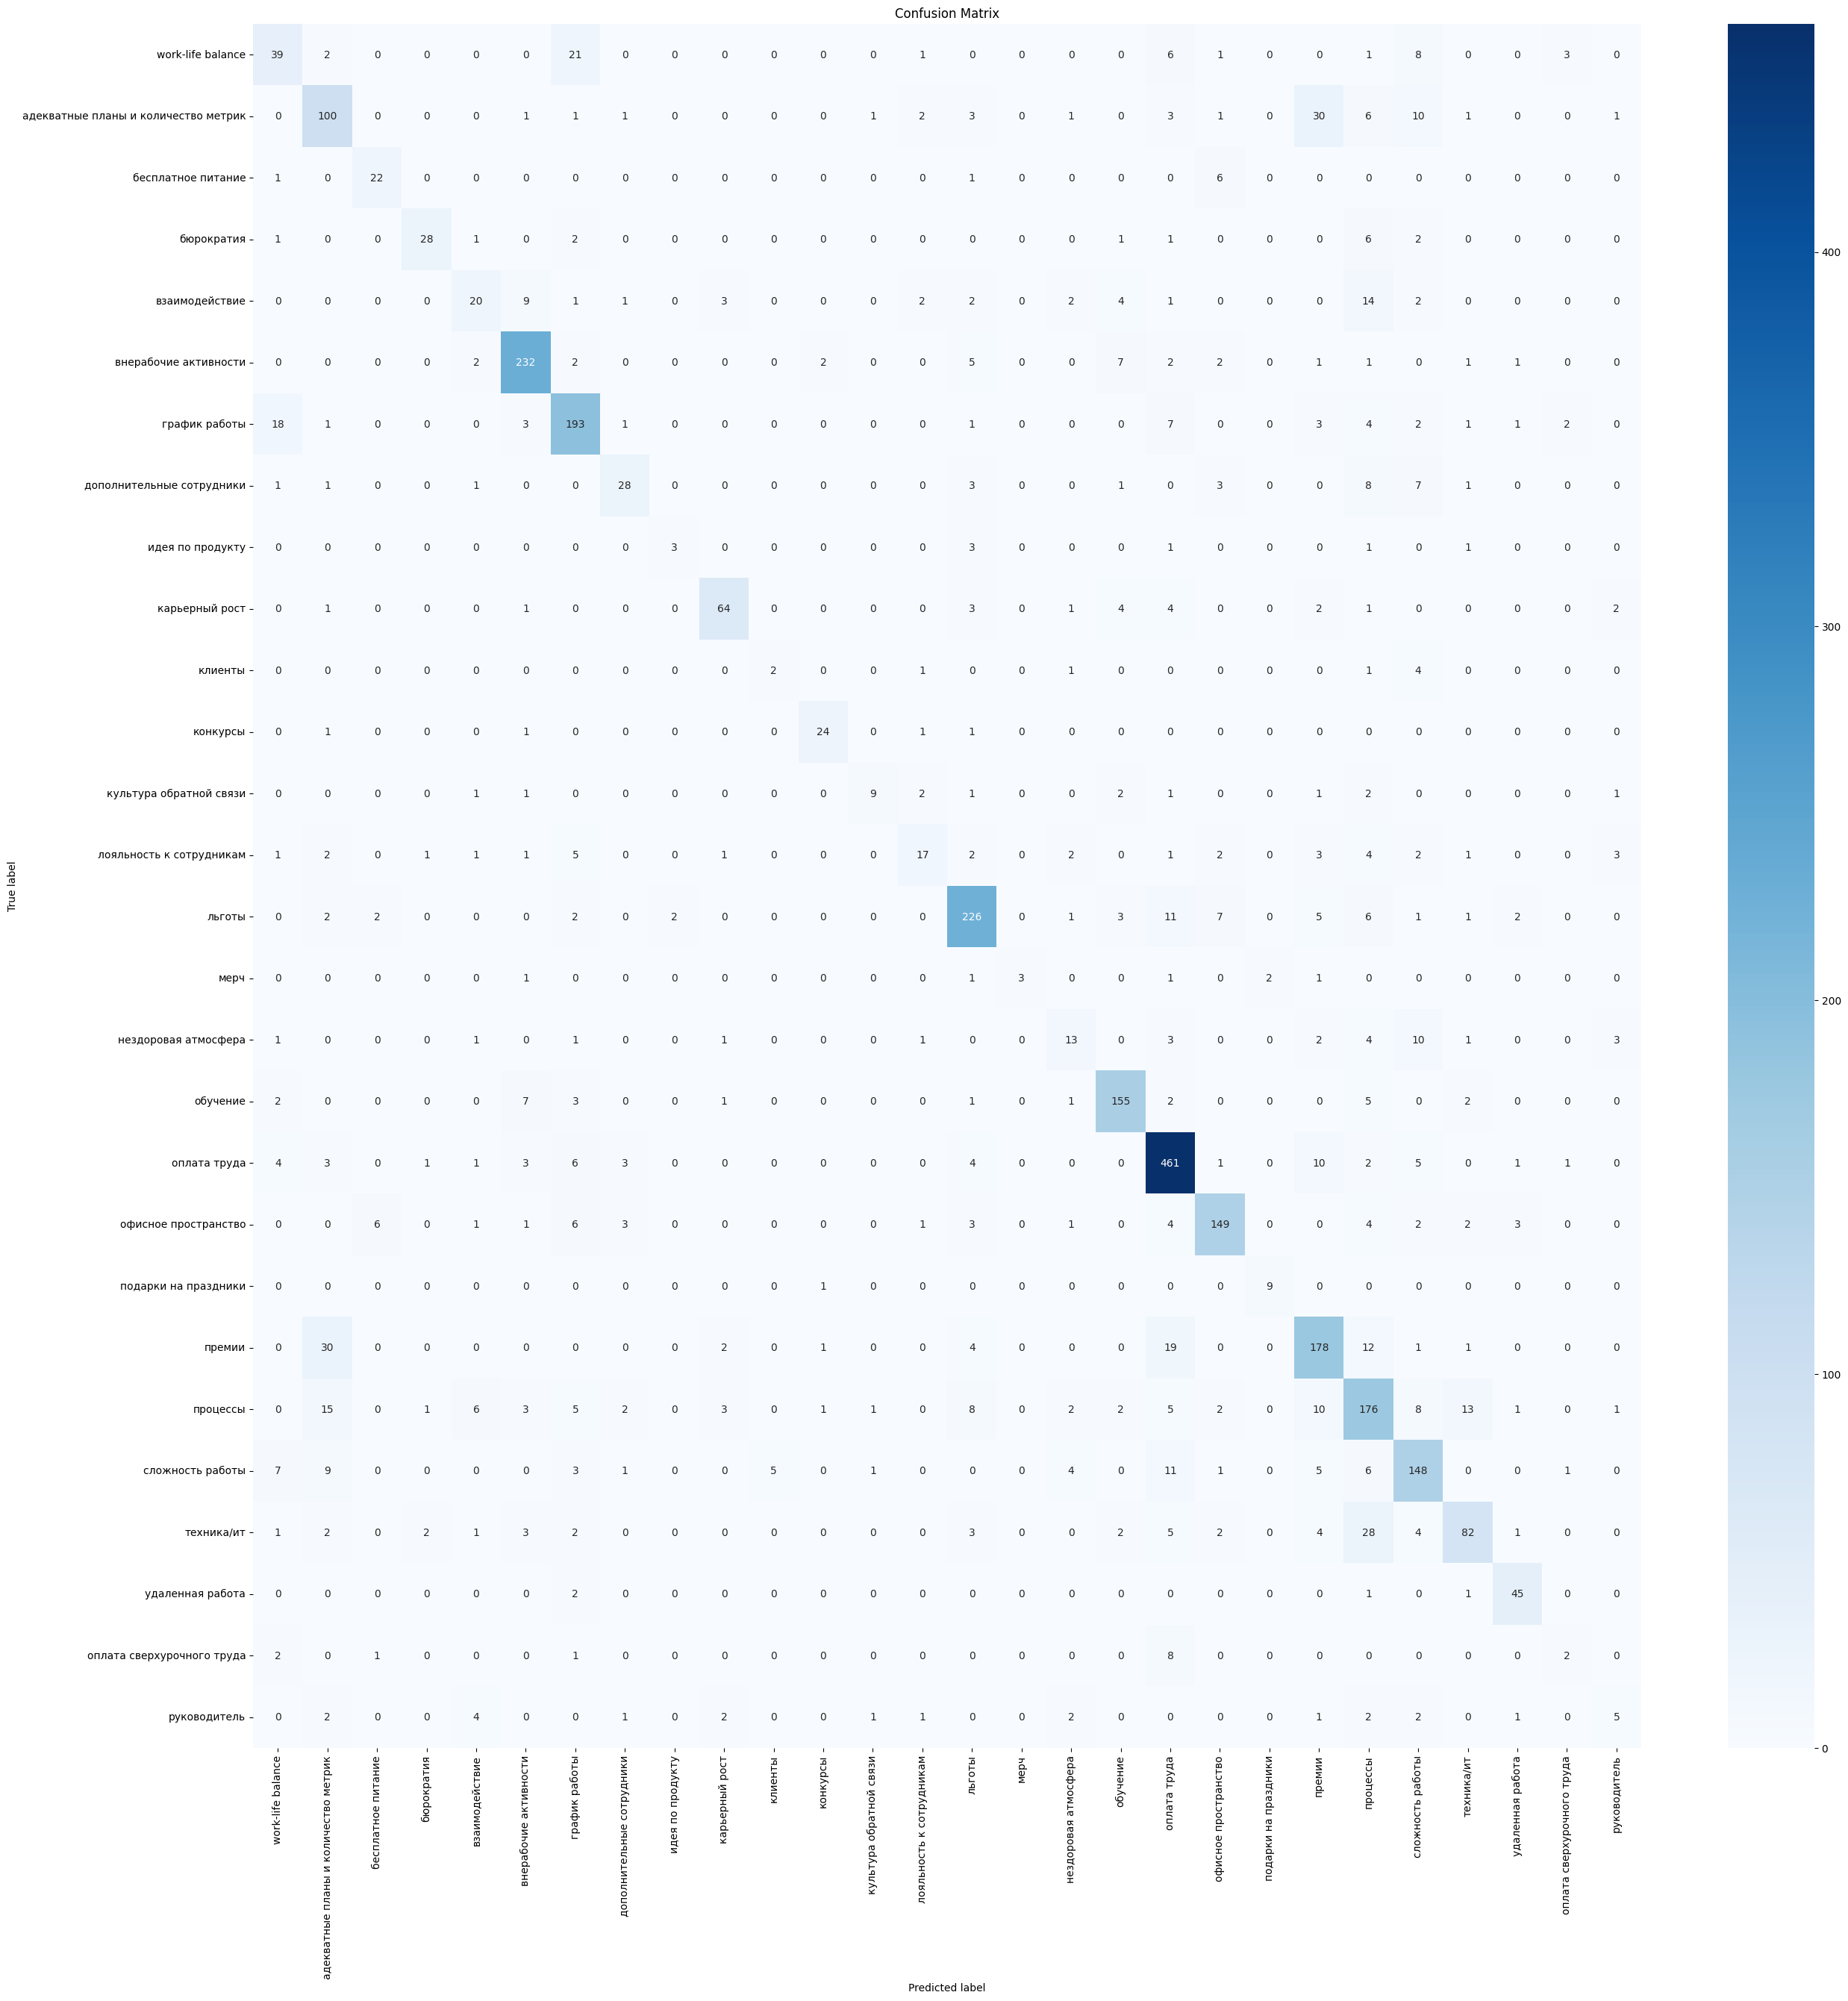

In [28]:
cats = {
    2 :  'work-life balance',
    3 :  'адекватные планы и количество метрик',
    4 :  'бесплатное питание',
    5 :  'бюрократия',
    6 :  'взаимодействие',
    7 :  'внерабочие активности',
    8 :  'график работы',
    9 :  'дополнительные сотрудники',
    10 : 'идея по продукту',
    11 : 'карьерный рост',
    12 : 'клиенты',
    13 : 'конкурсы',
    14 : 'культура обратной связи',
    15 : 'лояльность к сотрудникам',
    16 : 'льготы',
    17 : 'мерч',
    18 : 'нездоровая атмосфера',
    19 : 'обучение',
    20 : 'оплата труда',
    21 : 'офисное пространство',
    22 : 'подарки на праздники',
    23 : 'премии',
    24 : 'процессы',
    25 : 'сложность работы',
    26 : 'техника/ит',
    27 : 'удаленная работа',
    28 : 'оплата сверхурочного труда',
    29 : 'руководитель'
    }.values()

# Compute confusion matrix
cm = confusion_matrix(y_true, pred)

# Plot
plt.figure(figsize=(30, 30))  # set figure size
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cats, yticklabels=cats)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()
